In [76]:
""" !pip install pyts
!pip install dtaidistance """

' !pip install pyts\n!pip install dtaidistance '

# Домашнее задание

1. Генерим 21 сигналов (временных рядов), 3 класса по 7 образцов в каждом. 
Постарайтесь сделать их как можно более похожими, и в тоже время различными. 

1. Рассчитываем расстояние между ними по формуле Евклида и с помощью DTW

1. Описываем кратко полученные значения

1. Формируем из нагенеренных временных рядов набор данных для обучения

1. Разбиваем набор на train и test

1. Обучаем  классификаторы KNN с DTW, KNN со стандартной метрикой расстояния, TimeSeriesForest

1. Описываем кратко полученные результаты

In [77]:
import matplotlib.pyplot as plt
import numpy as np

Генерация сигнала

1 тип - гармонический (косинус)

2 тип - модифицированный синус

3 тип - пульс - сигнал

Для выполнения дз надо нагенерить 21 сигнал, по 7 сигналов каждого типа

In [78]:
def pulse(t):
    """Пульс сигнал"""
    return 1 * (abs(t) < 0.5)

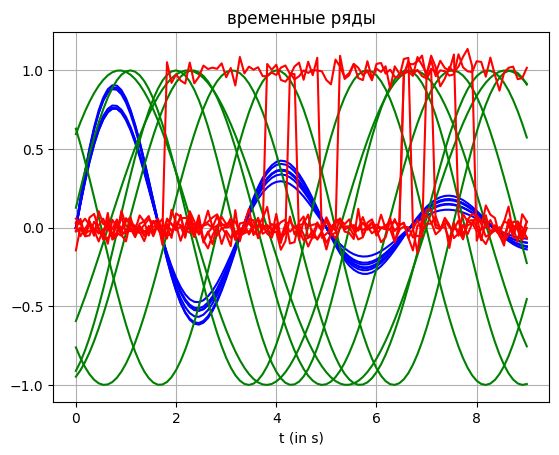

In [79]:
# индекс и отсчет времени в секундах
time_index = np.linspace(0, 9, 100)

tseries_list = {'Time': time_index}
d = np.random.random(size=10)


N = 7 #количество образцов в каждом типе сигналов


# гармонические колебания
f0 = 0.2

for i in range(N):
    phase = np.random.uniform(0, 2*np.pi)
    # Добавляем небольшой случайный сдвиг частоты
    freq = f0 + np.random.normal(0, 0.02)
    tseries_list["Tc"+str(i)] = np.cos(2*np.pi * freq * time_index + phase)

# модифицированный синус 
for i in range(N):
    amp = np.random.uniform(0.8, 1.2)
    decay = np.random.uniform(0.1, 0.3)
    tseries_list["Ts"+str(i)] = amp * np.sin(2*np.pi * 0.3 * time_index) * np.exp(-decay * time_index)

# пульс сигнал
for i in range(N):
    pulse_signal = np.zeros_like(time_index)
    start = np.random.randint(20, 80)
    width = np.random.randint(10, 30)
    pulse_signal[start:start+width] = 1.0
    # добавляем небольшой шум
    noise = np.random.normal(0, 0.05, len(time_index))
    tseries_list["Tp"+str(i)] = pulse_signal + noise

# отрисовка всех сигналов
for i in range(N):
    plt.plot(time_index, tseries_list["Ts"+str(i)], '-b')
for i in range(N):
    plt.plot(time_index, tseries_list["Tc"+str(i)], '-g')
for i in range(N):
    plt.plot(time_index, tseries_list["Tp"+str(i)], '-r')
            
plt.title(r'временные ряды')
plt.xlabel(r't (in s)')
plt.grid()

# Понимание Динамическое искажение (деформация) времени (Dynamic time warping, DTW)

DTW - это метод, который вычисляет оптимальное соответствие между двумя заданными последовательностями (например, временными рядами) с определенными ограничениями и правилами:

1. Каждый индекс из первой последовательности должен быть сопоставлен с одним или несколькими индексами из другой последовательности и наоборот

1. Первый индекс из первой последовательности должен совпадать с первым индексом из другой последовательности (но это не обязательно должно быть его единственным совпадением)

1. Последний индекс из первой последовательности должен совпадать с последним индексом из другой последовательности (но это не обязательно должно быть его единственным совпадением)

1. Отображение индексов из первой последовательности на индексы из другой последовательности должно монотонно возрастать, и наоборот, т. е. если j>i являются индексами из первой последовательности, то в другой последовательности не должно быть двух индексов l> k, так что индекс i совпадает с индексом l, а индекс j - с индексом k, и наоборот.

Рассмотрим два временных ряда $x$ и $x^{\prime}$ соответствующей длины n и m. Предполагается, что все элементы этих рядов лежат в одном и том же  p - одномерном пространство и точные временные метки, в которые происходят наблюдения, не принимаются во внимание, важен только их порядок.

Более формально задача оптимизации записывается в виде:

$
DTW_q({x}, {x}^\prime) =
    \min_{\pi \in \mathcal{A}({x}, {x}^\prime)}
        \left( \sum_{(i, j) \in \pi} d(x_i, x^\prime_j)^q \right)^{\frac{1}{q}}
$

 
Здесь путь выравнивания $\pi$  длины K  представляет собой последовательность K  пары индексов $((i_0,j_0),..,(i_{K-1},j_{K-1}))$
 и  $A(x,x^{\prime})$
 представляет собой набор всех допустимых путей. Чтобы считаться допустимым, путь должен удовлетворять следующим условиям:

Начало (соответственно, конец) временных рядов сопоставляются друг с другом:

$
\pi_0 = (0, 0)
$

$
\pi_{K-1} = (n - 1, m - 1)
$

Последовательность монотонно увеличивается в обоих $i$ и $j$  и все индексы временных рядов должны отображаться хотя бы один раз, что может быть записано как:

$
i_{k-1} \leq i_k \leq i_{k-1} + 1
$

$
j_{k-1} \leq j_k \leq j_{k-1} + 1
$


Другим способом представления  DTW является использование двоичной матрицы, ненулевые элементы которой соответствуют совпадениям между элементами временного ряда. Это представление связано с представлением последовательности индексов, использованным выше:

$
\begin{equation}
(A_\pi)_{i,j} = \left\{ \begin{array}{rl} 1 & \text{ if } (i, j) \in \pi \\
                                      0 & \text{ otherwise}
                        \end{array} \right. \,\,\,\,\,\,\, .
\end{equation}
$

Тогда  DTW может быть выражено через скалярные произведения следующим образом:

$
DTW_q({x}, {x}^\prime) =
    \min_{\pi \in \mathcal{A}({x}, {x}^\prime)}
        \left\langle A_\pi,  D_q({x}, {x}^\prime) \right\rangle^{\frac{1}{q}}
 $ 

Решение поставленной задачи оптимизации может быть найдено с помощью динамического программирования.
Обозначим:

$
R_{i,j} = DTW_q({x}_{\rightarrow i}, {x}^\prime_{\rightarrow j})^q
$

где ${x}_{\rightarrow i}$ - обозначает наблюдение ряда до отметки i

Тогда получаем реккурентную формулу:

$
\begin{aligned}
R_{i,j} 
    &= \min_{\pi \in \mathcal{A}({x}_{\rightarrow i}, {x}^\prime_{\rightarrow j})}
        \sum_{(k, l) \in \pi} d(x_k, x^\prime_l)^q \\
    &\stackrel{*}{=} d(x_i, x^\prime_j)^q +
        \min_{\pi \in \mathcal{A}({x}_{\rightarrow i}, {x}^\prime_{\rightarrow j})}
            \sum_{(k, l) \in \pi[:-1]} d(x_k, x^\prime_l)^q \\
    &\stackrel{**}{=} d(x_i, x^\prime_j)^q +
        \min ({\color{Blue}R_{i-1, j}}, {\color{Red}R_{i, j-1}}, {\color{ForestGreen}R_{i-1, j-1}})
\end{aligned}
$

\* - потому, что последний элемент на допустимом пути должен соответствовать последним элементам ряда.

** - результат условий смежности допустимых путей.

In [80]:
def distance_matrix(x, y, q) -> np.array:
    mdist = np.zeros((len(y), len(x)))
    for i in range(len(y)):
        for j in range(len(x)):
            mdist[i,j] = np.abs(x[j] - y[i])**q
    return mdist

In [81]:
# Посчитаем DTW для двух временных рядов
# Сначала напишем функцию, которая это все вычисляет


def DTW(x, x_s, q=1, isDTW=True):
    '''
        x: первый ряд
        x_s : второй ряд
        q : степень для вычисления базового расстояния
    '''
    N = len(x) # Считаем, что ряды равной длины. Но это не всегда так, перепишите функцию для 
               # вычисления расстояния между рядами, длины которых не равны
    
    # Строим матрицу согласно реккурентной формуле, полученной выше. Матрица в нашем случае будет размерности 

    dist = distance_matrix(x,x_s,q=2)
    
    R = [[0] * (N+1) for i in range(N+1)]
   
    for i in range(1,N): 
        R[i][0] = dist[i,0] + R[i-1][0] 
        R[0][i] = dist[0,i] + R[0][i-1]
    
    # проверяем, что записалось
    #print("Начинаем заполнять матрицу R")
    #for i in range(N+1): 
    #    print(R[i])

    k = 0
    if isDTW:
        k = 1
    
    # начинаем расчет по реккурентной формуле
  
    for i in range(1, N+1):
        for j in range(1, N+1):
            if isDTW:
                R[i][j] = dist[i-1,j-1] + min(R[i-1][j], R[i][j-1], R[i-1][j-1])
            else:
                # Евклидово (без DTW) – просто сумма расстояний по диагонали
                R[i][j] = dist[i-1,j-1] + R[i-1][j-1]   # путь только по диагонали
                
    # проверяем, что записалось
    print("\nпосле заполнения матрицы R")
    for i in range(N+1): 
        print(R[i])

    # ищем минимальный путь. Начинаем от нижнего правого угла.
    pth = []   # лист с кортежами индексов пути
    i = N
    j = N
    while i >= 0 and j >= 0:
        pth.append((i,j))
        if R[i][j-1] <= R[i-1][j-1] and R[i][j-1] <= R[i-1][j]:
            I = i
            J = j-1                
        
        if R[i-1][j] <= R[i-1][j-1] and R[i-1][j] <= R[i][j-1]:
            I = i - 1
            J = j 

        if R[i-1][j-1] <= R[i][j-1] and R[i-1][j-1] <= R[i-1][j]:
            I = i - 1
            J = j - 1
        
        i = I
        j = J
    
            
    print("\nПуть:")
    print(pth)

    #Считаем расстояние между двумя рядами
    s = 0
    for l in pth:
        s += R[l[0]][l[1]]
    s = s/len(pth) 

    return s, pth, R


In [82]:
# Посчитаем DTW для двух временных рядов

#для простоты выделяем ряды, которые будем сравнивать
x = np.abs(tseries_list.get("Ts1", np.zeros(100))) # Если tseries_list не заполнен
x_s = np.abs(tseries_list.get("Ts6", np.zeros(100)))
x_p = np.abs(tseries_list.get("Tp2", np.zeros(100)))

s1 = DTW(x, x_s, q=2)
s2 = DTW(x, x_p, q=2)
print(f"DTW\nTs1 и Ts6 = {s1[0]}     Ts1 и Tp2 = {s2[0]}")

s11 = DTW(x, x_s, q=2, isDTW=False)
s21 = DTW(x, x_p, q=2, isDTW=False)
print(f"Euclidean\nTs1 и Ts6 = {s11[0]}     Ts1 и Tp2 = {s21[0]}")


после заполнения матрицы R
[0, np.float64(0.03290485967173782), np.float64(0.1546906718399478), np.float64(0.4031991906759267), np.float64(0.795662853459594), np.float64(1.3287804355753514), np.float64(1.9811009595147016), np.float64(2.7172347567253077), np.float64(3.4932481632976575), np.float64(4.262523574369767), np.float64(4.981379892374333), np.float64(5.613840192108986), np.float64(6.135086110347124), np.float64(6.533329197783302), np.float64(6.810033191449403), np.float64(6.978613652576423), np.float64(7.061901938022564), np.float64(7.088773819166211), np.float64(7.090400746990703), np.float64(7.096582373796897), np.float64(7.132567650351405), np.float64(7.216679185401733), np.float64(7.358935849492626), np.float64(7.560737845110254), np.float64(7.815552447998662), np.float64(8.110431161366186), np.float64(8.428110561562159), np.float64(8.749405859165531), np.float64(9.055599811446713), np.float64(9.330557438884588), np.float64(9.562352735271752), np.float64(9.744268353765337),

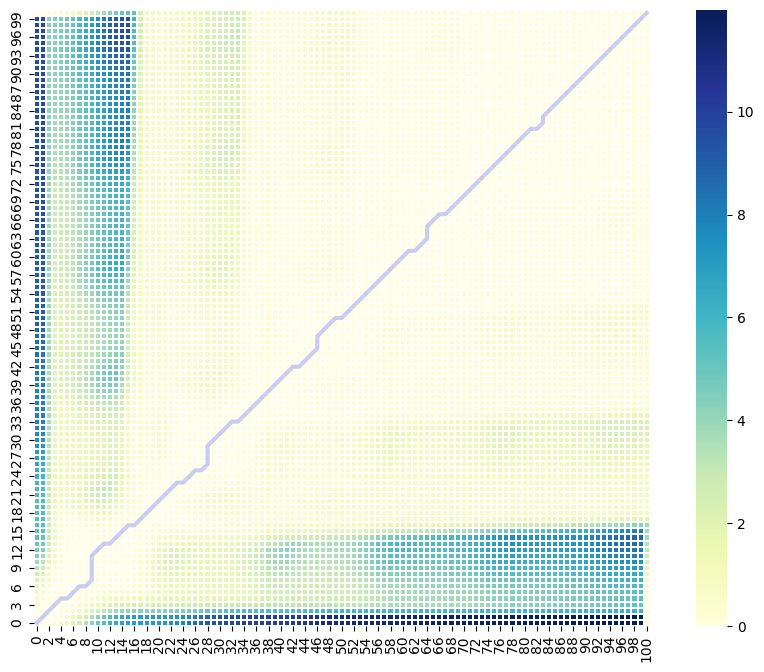

In [83]:
import seaborn as sbn
# Отрисуем матрицы весов расстояний Ts1 и Ts3 

cost_matrix = s1[2]
warp_path = s1[1]

fig, ax = plt.subplots(figsize=(12, 8))
ax = sbn.heatmap(cost_matrix, square=True, linewidths=0.1, cmap="YlGnBu", ax=ax)
ax.invert_yaxis()


path_x = [p[0] for p in warp_path]
path_y = [p[1] for p in warp_path]

# Align the path from the center of each cell
path_xx = [x+0.5 for x in path_x]
path_yy = [y+0.5 for y in path_y]

ax.plot(path_xx, path_yy, color='blue', linewidth=3, alpha=0.2)

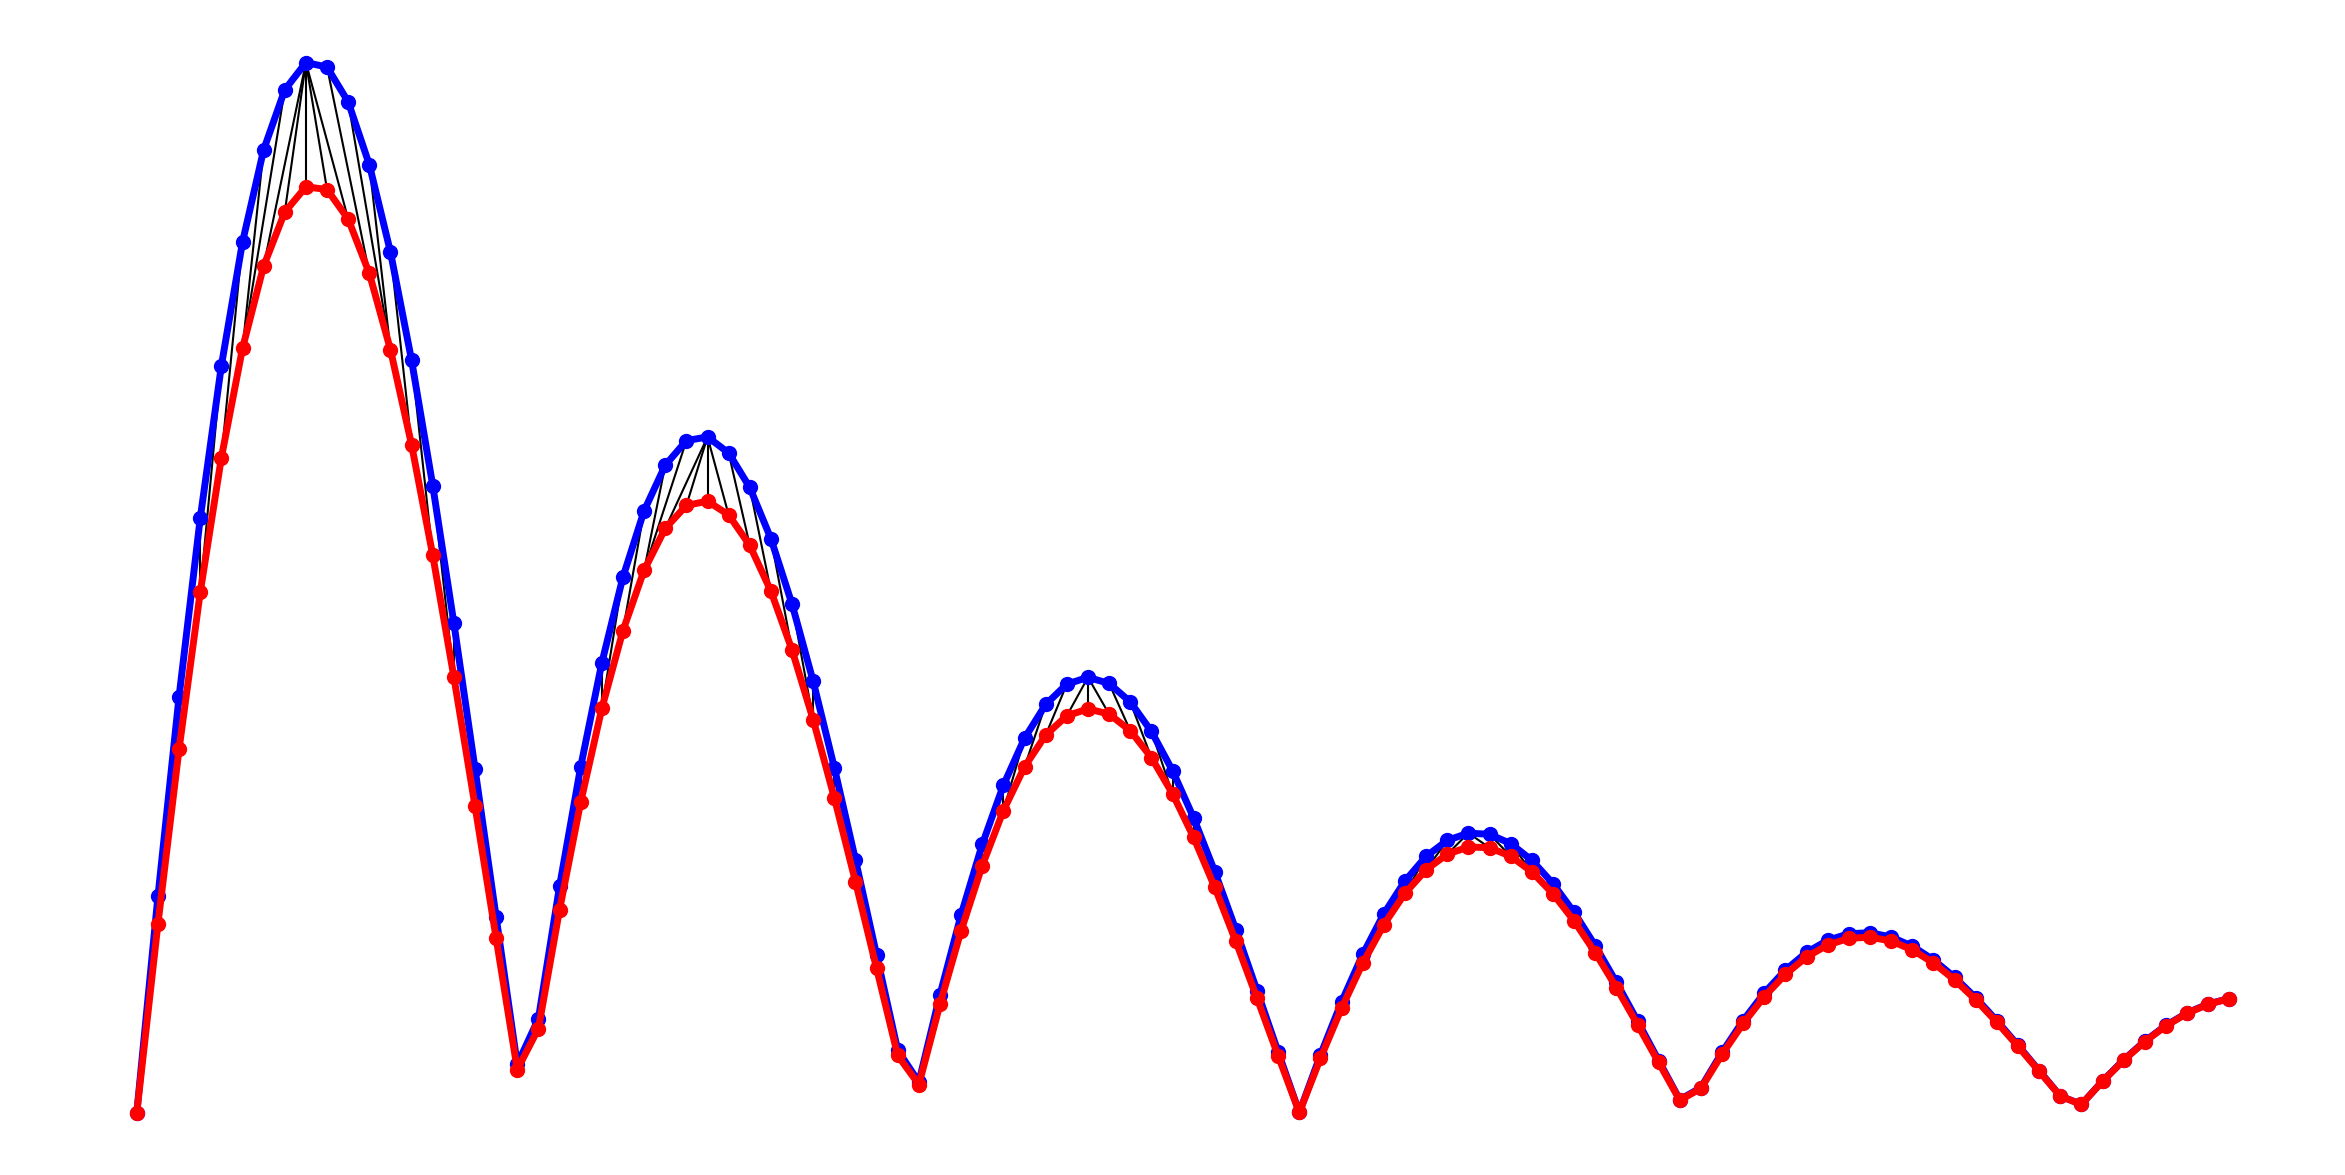

In [84]:
fig, ax = plt.subplots(figsize=(30, 15))


warp_path = s1[1]
x1 = x
x2 = x_s

# Remove the border and axes ticks
fig.patch.set_visible(True)
ax.axis('off')

for [map_x, map_y] in warp_path:   
    ax.set_facecolor('white')
    ax.plot([map_x-1, map_y-1], [x1[map_x-1], x2[map_y-1]], '-k')

ax.plot(x1, color='blue', marker='o', markersize=10, linewidth=5)
ax.plot(x2, color='red', marker='o', markersize=10, linewidth=5)
ax.tick_params(axis="both", which="major", labelsize=18)

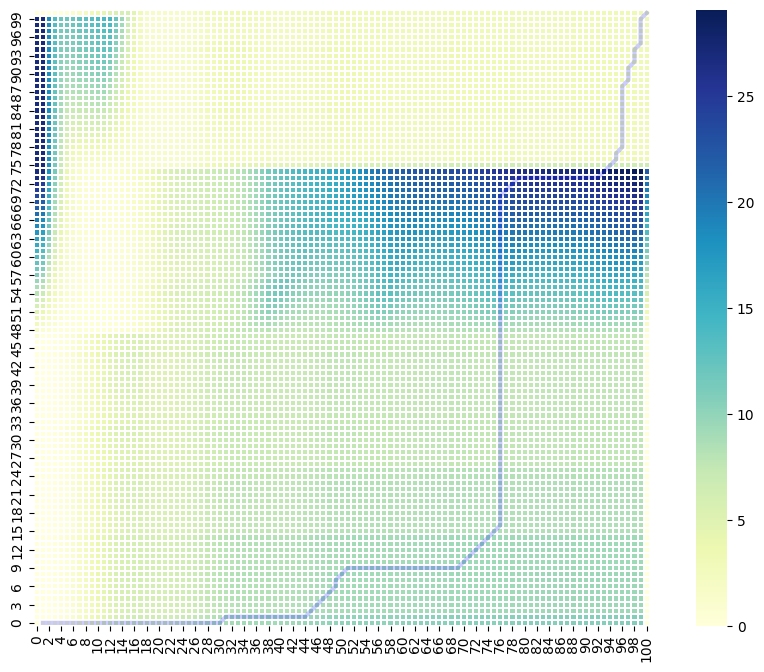

In [85]:
# Отрисуем матрицы весов расстояний Ts1 и Tp1

cost_matrix = s2[2]
warp_path = s2[1]

fig, ax = plt.subplots(figsize=(12, 8))
ax = sbn.heatmap(cost_matrix, square=True, linewidths=0.1, cmap="YlGnBu", ax=ax)
ax.invert_yaxis()


path_x = [p[0] for p in warp_path]
path_y = [p[1] for p in warp_path]

# Align the path from the center of each cell
path_xx = [x+0.5 for x in path_x]
path_yy = [y+0.5 for y in path_y]

ax.plot(path_xx, path_yy, color='blue', linewidth=3, alpha=0.2)

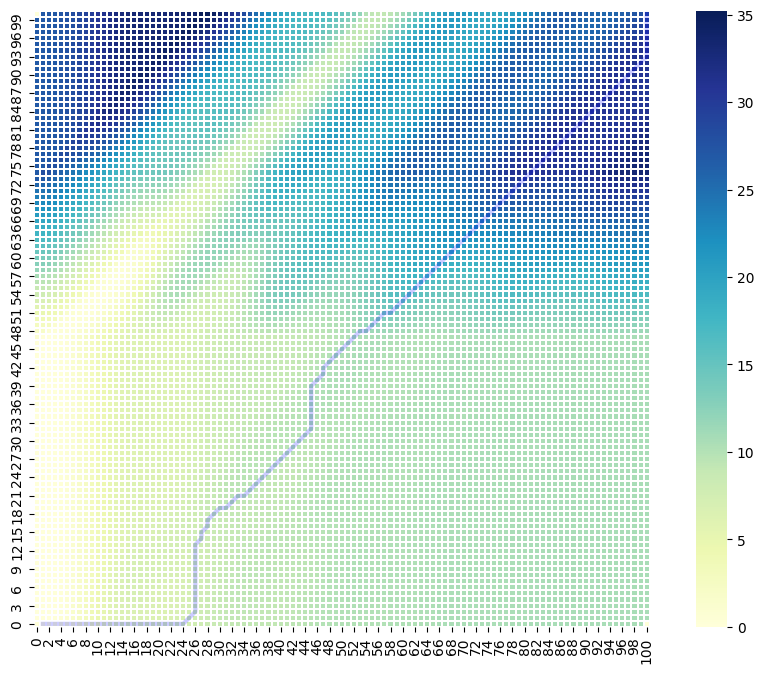

In [86]:
# Отрисуем матрицы весов расстояний Ts1 и Tp1 без DTW

cost_matrix = s21[2]
warp_path = s21[1]

fig, ax = plt.subplots(figsize=(12, 8))
ax = sbn.heatmap(cost_matrix, square=True, linewidths=0.1, cmap="YlGnBu", ax=ax)
ax.invert_yaxis()


path_x = [p[0] for p in warp_path]
path_y = [p[1] for p in warp_path]

# Align the path from the center of each cell
path_xx = [x+0.5 for x in path_x]
path_yy = [y+0.5 for y in path_y]

ax.plot(path_xx, path_yy, color='blue', linewidth=3, alpha=0.2)

А теперь попробуем вычислить тоже самое, но с помощью встроенных функций Python

In [87]:
from dtaidistance import dtw

x = np.abs(tseries_list.get("Ts1", np.zeros(100)))
x_s = np.abs(tseries_list.get("Ts6", np.zeros(100)))

# Вычисляем расстояние и пути с помощью встроенной функции dtw.warping_paths
distance, paths = dtw.warping_paths(x, x_s)

print(distance)
print(paths)

0.2714185684833379
[[0.                inf        inf ...        inf        inf        inf]
 [       inf 0.         0.15840289 ... 3.10452904 3.10585753 3.10732484]
 [       inf 0.18139697 0.02299408 ... 2.07192469 2.07390308 2.07568193]
 ...
 [       inf 3.45918063 2.49264368 ... 0.2714184  0.27151605 0.27177807]
 [       inf 3.46037985 2.4935523  ... 0.27153327 0.27141853 0.271454  ]
 [       inf 3.46170088 2.4943424  ... 0.27181761 0.27146087 0.27141857]]


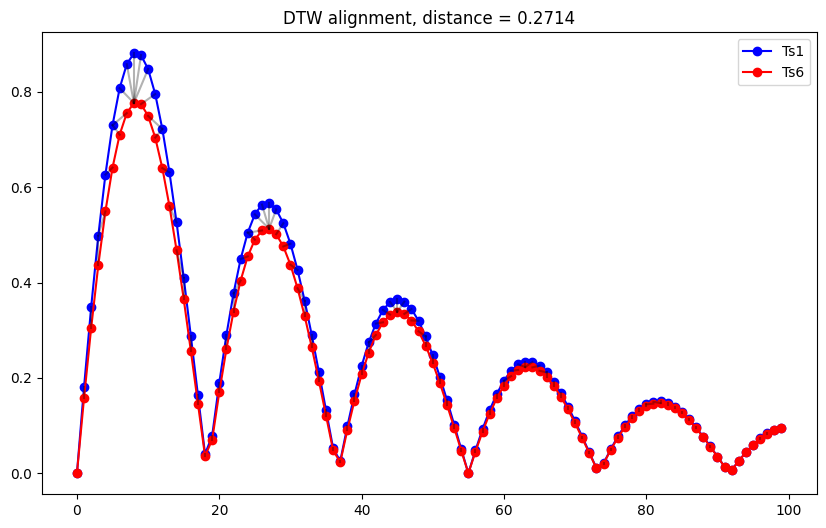

In [88]:
from dtaidistance import dtw
import matplotlib.pyplot as plt
import numpy as np

s1 = x
s2 = x_s

# Вычисляем DTW, получаем расстояние и матрицу
distance, paths = dtw.warping_paths(s1, s2, window=25, psi=2)

# Получаем лучший путь
best_path = dtw.best_path(paths)

# Визуализируем только лучший путь (без матрицы)
plt.figure(figsize=(10, 6))
plt.plot(s1, 'b-o', label='Ts1')
plt.plot(s2, 'r-o', label='Ts6')
for (i, j) in best_path:
    plt.plot([i, j], [s1[i], s2[j]], 'k-', alpha=0.3)
plt.legend()
plt.title(f'DTW alignment, distance = {distance:.4f}')
plt.show()

In [89]:
x = np.abs(tseries_list["Ts1"])
x_p = np.abs(tseries_list["Tp2"])


distance, paths = dtw.warping_paths(x, x_p)
print(distance)
print(paths)

1.8093724521493557
[[0.                inf        inf ...        inf        inf        inf]
 [       inf 0.02617065 0.06007539 ... 5.19113761 5.19147044 5.19161664]
 [       inf 0.157417   0.1299834  ... 4.29548523 4.29723482 4.29959476]
 ...
 [       inf 3.26810454 3.07498764 ... 1.81017285 1.80819631 1.80857645]
 [       inf 3.26874934 3.07521045 ... 1.81093505 1.80848494 1.80894768]
 [       inf 3.26948716 3.07549114 ... 1.81177635 1.80886015 1.80937245]]


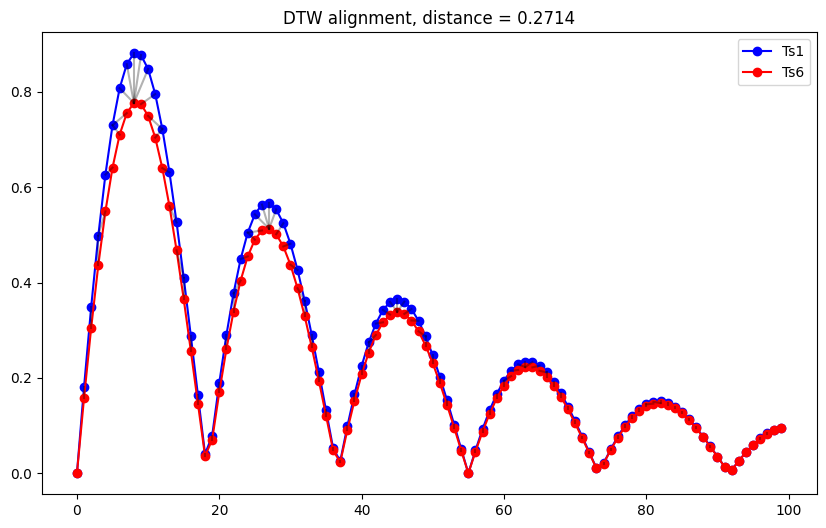

In [90]:
from dtaidistance import dtw
import matplotlib.pyplot as plt
import numpy as np

s1 = x
s2 = x_s

# Вычисляем DTW, получаем расстояние и матрицу
distance, paths = dtw.warping_paths(s1, s2, window=25, psi=2)

# Получаем лучший путь
best_path = dtw.best_path(paths)

# Визуализируем только лучший путь (без матрицы)
plt.figure(figsize=(10, 6))
plt.plot(s1, 'b-o', label='Ts1')
plt.plot(s2, 'r-o', label='Ts6')
for (i, j) in best_path:
    plt.plot([i, j], [s1[i], s2[j]], 'k-', alpha=0.3)
plt.legend()
plt.title(f'DTW alignment, distance = {distance:.4f}')
plt.show()

In [91]:
# переделываем датасет так, чтобы с ним можно было бы работать

x = []  #значения
Y = []  # целевая переменная

for v in tseries_list:
    if v!= 'Time':
        x.append(tseries_list[v])
        c = v[:-1]
        if c == "Ts":
            Y.append(0)
        elif c == "Tc":
            Y.append(1)
        else: Y.append(2)


arr = np.arange(len(Y))
np.random.shuffle(arr)


print(Y)

X_train = []
X_test = []
y_train = []
y_test = []

# Разделение: последние 5 образцов – тест, остальные – обучение
test_indices = arr[-5:]
train_indices = arr[:-5]

X_train = [x[i] for i in train_indices]
X_test  = [x[i] for i in test_indices]
y_train = [Y[i] for i in train_indices]
y_test  = [Y[i] for i in test_indices]

[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2]


In [92]:
from pyts.classification import KNeighborsClassifier

clf = KNeighborsClassifier(metric='dtw')
clf.fit(X_train, y_train)
print(f"Accuracy {clf.score(X_test, y_test)}")
print(f"Вектор вероятности принадлежности к классам {clf.predict_proba(X_test[2].reshape(1, -1))}")
print(f"Истинный класс для предсказаний {y_test[2]}")

c:\Users\user20\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\user20\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Accuracy 1.0
Вектор вероятности принадлежности к классам [[0. 0. 1.]]
Истинный класс для предсказаний 2


c:\Users\user20\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\user20\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\user20\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\user20\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\user20\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ut

In [93]:
import numpy as np 
from pyts.classification import TimeSeriesForest
import matplotlib.pyplot as plt

clf = TimeSeriesForest(random_state=43)
clf.fit(X_train, y_train)
print(f"Accuracy {clf.score(X_test, y_test)}")
print(f"Вектор вероятности принадлежности к классам {clf.predict_proba(X_test[2].reshape(1, -1))}")
print(f"Истинный класс для предсказаний {y_test[2]}")

Accuracy 1.0
Вектор вероятности принадлежности к классам [[0.118 0.152 0.73 ]]
Истинный класс для предсказаний 2


In [94]:
from pyts.classification import KNeighborsClassifier

clf_eucl = KNeighborsClassifier(metric='euclidean')
clf_eucl.fit(X_train, y_train)
print(f"Accuracy {clf_eucl.score(X_test, y_test)}")
print(f"Вектор вероятности принадлежности к классам {clf_eucl.predict_proba(X_test[2].reshape(1, -1))}")
print(f"Истинный класс для предсказаний {y_test[2]}")

Accuracy 1.0
Вектор вероятности принадлежности к классам [[0. 0. 1.]]
Истинный класс для предсказаний 2
